<a href="https://colab.research.google.com/github/nabillahumi/S5-Mesin_Learning/blob/main/Jobsheet4/Tugas%20Praktikum%20(K-Means).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##1. Tugas K-Means

Buatlah sebuah model K-Means dengan ketentuan,

1. Gunakan data 'Mall_Customers.csv'

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Load dataset
df = pd.read_csv('Mall_Customers.csv')
print("5 data teratas:")
print(df.head())

5 data teratas:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


2. Tentukan fitur apa yang tepat untuk melakukan clustering (minimal 2)

In [2]:
# Select 2 fitur utama untuk clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

3. Buatlah model K-Means dengan mempertimbangkan jumlah
k yang terbaik.

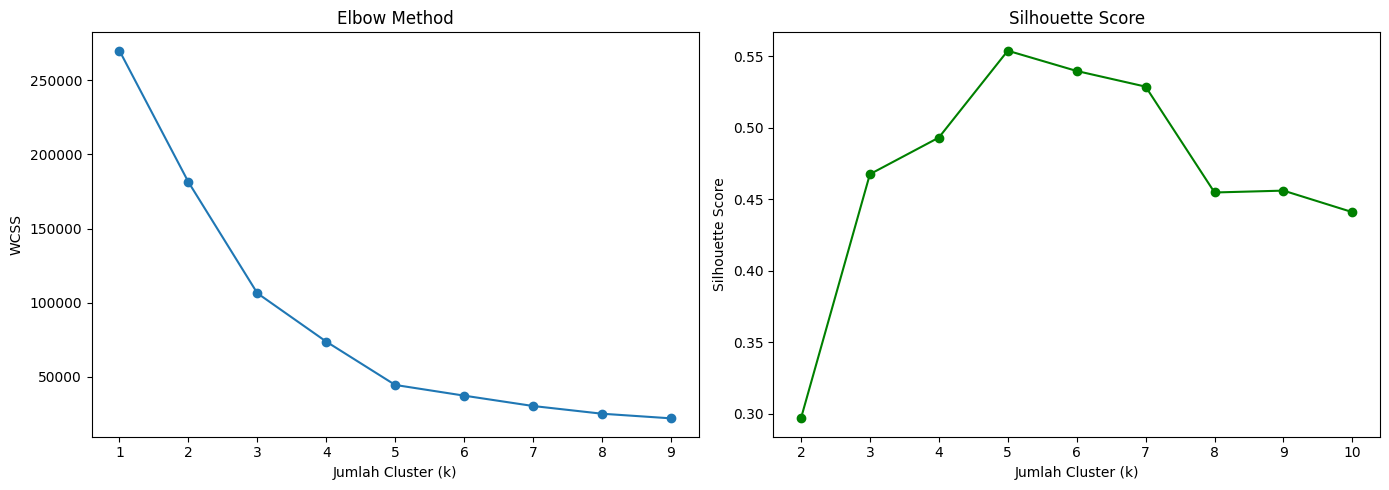

Berdasarkan grafik Elbow dan Silhouette Score, jumlah k terbaik adalah k = 5.


In [5]:
wcss = []               # Menyimpan nilai WCSS (Inertia) untuk Elbow Method
silhouette_scores = []  # Menyimpan nilai Silhouette Score
K_range = range(2, 11)  # Menguji nilai k dari 2 sampai 10

for k in K_range:
    # Inisialisasi model K-Means dengan k tertentu
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X) # Melatih model

    # Simpan nilai WCSS dan Silhouette Score
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))

# Membuat canvas untuk 2 plot grafik secara bersisian (1 baris, 2 kolom)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Elbow Method ---
# Mengulang k dari 1 sampai 9 khusus untuk Elbow Method
wcss_elbow = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X).inertia_ for k in range(1, 10)]
ax[0].plot(range(1, 10), wcss_elbow, marker='o')
ax[0].set_title('Elbow Method')
ax[0].set_xlabel('Jumlah Cluster (k)')
ax[0].set_ylabel('WCSS')

# --- Plot 2: Silhouette Score ---
ax[1].plot(K_range, silhouette_scores, marker='o', color='green')
ax[1].set_title('Silhouette Score')
ax[1].set_xlabel('Jumlah Cluster (k)')
ax[1].set_ylabel('Silhouette Score')

plt.tight_layout() # Merapikan tata letak grafik
plt.show()         # Menampilkan grafik

print("Berdasarkan grafik Elbow dan Silhouette Score, jumlah k terbaik adalah k = 5.")

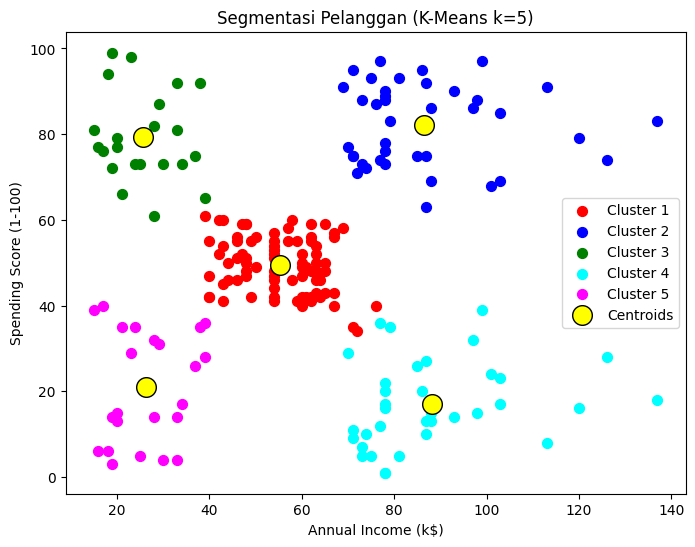

In [6]:
# Inisialisasi dan latih model dengan k = 5
kmeans_best = KMeans(n_clusters=5, random_state=42, n_init=10)
y_kmeans = kmeans_best.fit_predict(X)

# Visualisasi Hasil Cluster
plt.figure(figsize=(8, 6))
colors = ['red', 'blue', 'green', 'cyan', 'magenta']
labels_name = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4', 'Cluster 5']

for i in range(5):
    plt.scatter(X[y_kmeans == i, 0], X[y_kmeans == i, 1], s=50, c=colors[i], label=labels_name[i])

# Plot Centroid
plt.scatter(kmeans_best.cluster_centers_[:, 0], kmeans_best.cluster_centers_[:, 1], s=200, c='yellow', edgecolors='black', label='Centroids')

plt.title('Segmentasi Pelanggan (K-Means k=5)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()